In [1]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.fftpack import fft

def get_fft_values(y_values, T, N, f_s):
   f_values = np.linspace(0.0, 1.0/(2.0*T), N//2)
   fft_values_ = fft(y_values)
   fft_values = 2.0/N * np.abs(fft_values_[0:N//2])
   return f_values, fft_values

t_n = 1
N = 100000
T = t_n / N
f_s = 1/T

xa = np.linspace(0, t_n, num=N)
xb = np.linspace(0, t_n/4, num=N//4)

frequencies = [4, 30, 60, 90]
y1a, y1b = np.sin(2*np.pi*frequencies[0]*xa), np.sin(2*np.pi*frequencies[0]*xb)
y2a, y2b = np.sin(2*np.pi*frequencies[1]*xa), np.sin(2*np.pi*frequencies[1]*xb)
y3a, y3b = np.sin(2*np.pi*frequencies[2]*xa), np.sin(2*np.pi*frequencies[2]*xb)
y4a, y4b = np.sin(2*np.pi*frequencies[3]*xa), np.sin(2*np.pi*frequencies[3]*xb)

composite_signal1 = y1a + y2a + y3a + y4a
composite_signal2 = np.concatenate([y1b, y2b, y3b, y4b])

f_values1, fft_values1 = get_fft_values(composite_signal1, T, N, f_s)
f_values2, fft_values2 = get_fft_values(composite_signal2, T, N, f_s)

# print(f_values1)

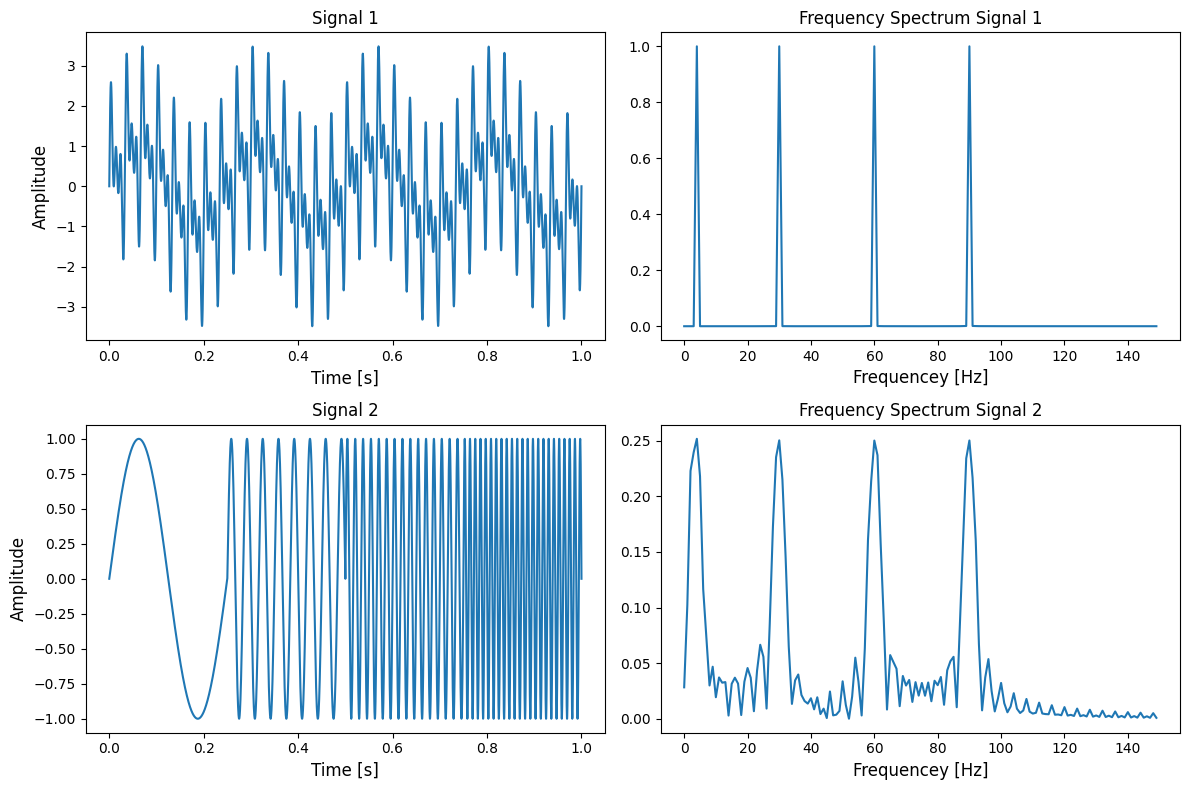

In [2]:

fig, axarr = plt.subplots(nrows=2, ncols=2, figsize=(12,8))
axarr[0,0].set_title('Signal 1', fontsize=12)
axarr[0,0].set_xlabel('Time [s]', fontsize=12)
axarr[0,0].set_ylabel('Amplitude', fontsize=12)
axarr[0,0].plot(xa, composite_signal1)

axarr[1,0].set_title('Signal 2', fontsize=12)
axarr[1,0].set_xlabel('Time [s]', fontsize=12)
axarr[1,0].set_ylabel('Amplitude', fontsize=12)
axarr[1,0].plot(xa, composite_signal2)

axarr[0,1].set_title('Frequency Spectrum Signal 1', fontsize=12)
axarr[0,1].set_xlabel('Frequencey [Hz]', fontsize=12)
axarr[0,1].plot(f_values1[:150], fft_values1[:150])

axarr[1,1].set_title('Frequency Spectrum Signal 2', fontsize=12)
axarr[1,1].set_xlabel('Frequencey [Hz]', fontsize=12)
axarr[1,1].plot(f_values2[:150], fft_values2[:150])
plt.tight_layout()
plt.show()

In [3]:
import pywt

print(f'wavelet family long format:\n{pywt.families(short=False)}')

print(f'\nwavelet family short format:\n{pywt.families(short=True)}')

wavelet family long format:
['Haar', 'Daubechies', 'Symlets', 'Coiflets', 'Biorthogonal', 'Reverse biorthogonal', 'Discrete Meyer (FIR Approximation)', 'Gaussian', 'Mexican hat wavelet', 'Morlet wavelet', 'Complex Gaussian wavelets', 'Shannon wavelets', 'Frequency B-Spline wavelets', 'Complex Morlet wavelets']

wavelet family short format:
['haar', 'db', 'sym', 'coif', 'bior', 'rbio', 'dmey', 'gaus', 'mexh', 'morl', 'cgau', 'shan', 'fbsp', 'cmor']


In [4]:
wavelet_families = pywt.families(short=False)
discrete_mother_wavelets = pywt.wavelist(kind='discrete')
continuous_mother_wavelets = pywt.wavelist(kind='continuous')

print("PyWavelets contains the following families: ")
print(wavelet_families)
print()
print("PyWavelets contains the following Continuous families: ")
print(continuous_mother_wavelets)
print()
print("PyWavelets contains the following Discrete families: ")
print(discrete_mother_wavelets)
print()
for family in pywt.families():
    print("    * The {} family contains: {}".format(family, pywt.wavelist(family)))

PyWavelets contains the following families: 
['Haar', 'Daubechies', 'Symlets', 'Coiflets', 'Biorthogonal', 'Reverse biorthogonal', 'Discrete Meyer (FIR Approximation)', 'Gaussian', 'Mexican hat wavelet', 'Morlet wavelet', 'Complex Gaussian wavelets', 'Shannon wavelets', 'Frequency B-Spline wavelets', 'Complex Morlet wavelets']

PyWavelets contains the following Continuous families: 
['cgau1', 'cgau2', 'cgau3', 'cgau4', 'cgau5', 'cgau6', 'cgau7', 'cgau8', 'cmor', 'fbsp', 'gaus1', 'gaus2', 'gaus3', 'gaus4', 'gaus5', 'gaus6', 'gaus7', 'gaus8', 'mexh', 'morl', 'shan']

PyWavelets contains the following Discrete families: 
['bior1.1', 'bior1.3', 'bior1.5', 'bior2.2', 'bior2.4', 'bior2.6', 'bior2.8', 'bior3.1', 'bior3.3', 'bior3.5', 'bior3.7', 'bior3.9', 'bior4.4', 'bior5.5', 'bior6.8', 'coif1', 'coif2', 'coif3', 'coif4', 'coif5', 'coif6', 'coif7', 'coif8', 'coif9', 'coif10', 'coif11', 'coif12', 'coif13', 'coif14', 'coif15', 'coif16', 'coif17', 'db1', 'db2', 'db3', 'db4', 'db5', 'db6', 'db7'

/Users/zhangjw/Library/Caches/pypoetry/virtualenvs/pestdataprocess-ej7BuNox-py3.10/lib/python3.10/site-packages/matplotlib/cbook/__init__.py:1369: ComplexWarning: Casting complex values to real discards the imaginary part
  return np.asarray(x, float)


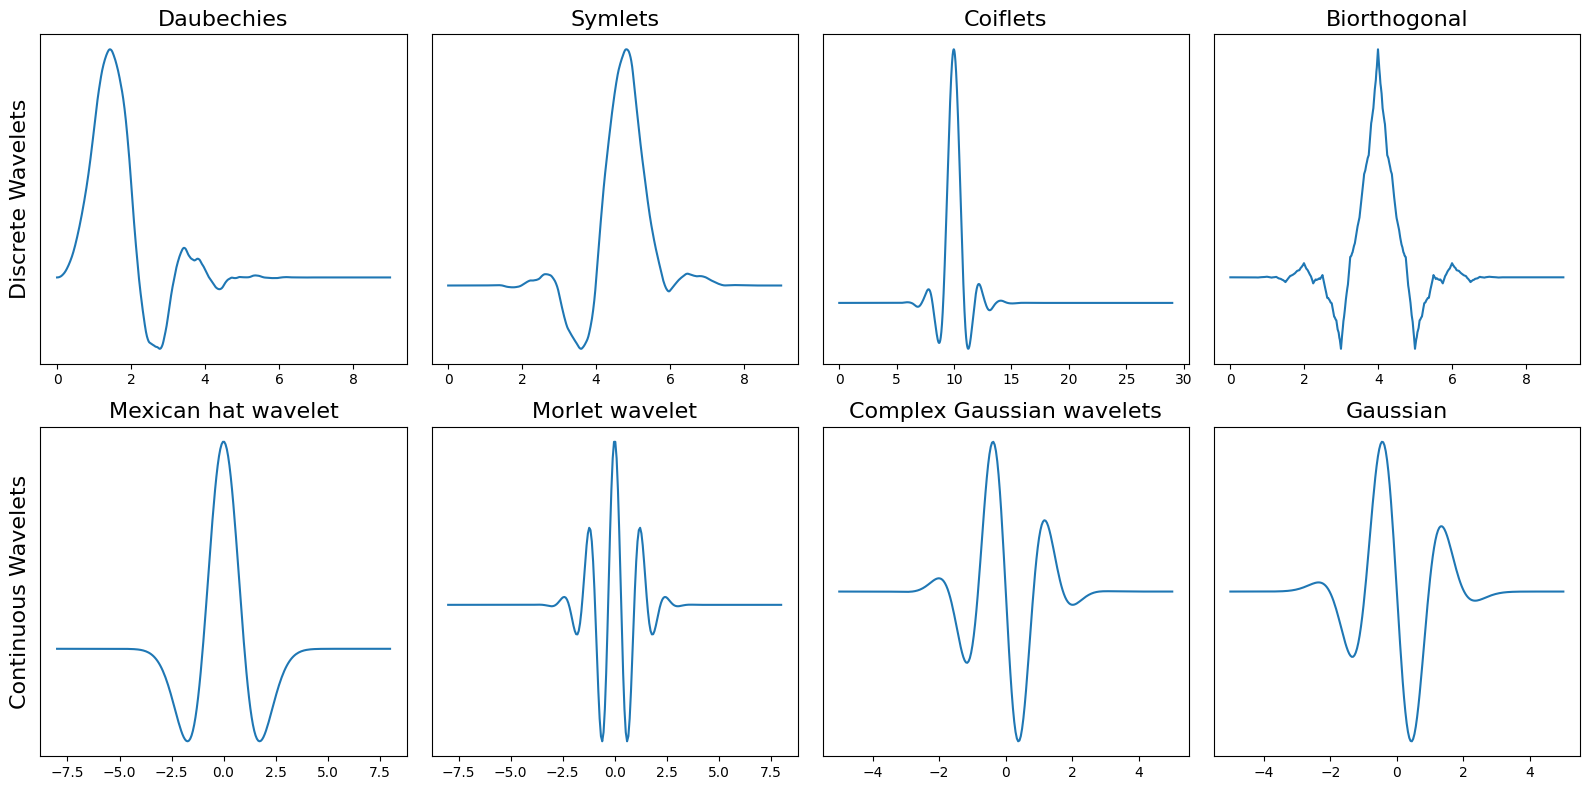

In [5]:

continuous_wavelets = ['mexh', 'morl', 'cgau5', 'gaus5']
discrete_wavelets = ['db5', 'sym5', 'coif5', 'bior2.4'] 

list_list_wavelets = [discrete_wavelets, continuous_wavelets]
list_funcs = [pywt.Wavelet, pywt.ContinuousWavelet]
 
fig, axarr = plt.subplots(nrows=2, ncols=4, figsize=(16,8))
for ii, list_wavelets in enumerate(list_list_wavelets):
    func = list_funcs[ii]
    row_no = ii
    for col_no, waveletname in enumerate(list_wavelets):
        wavelet = func(waveletname)
        family_name = wavelet.family_name
        biorthogonal = wavelet.biorthogonal
        orthogonal = wavelet.orthogonal
        symmetry = wavelet.symmetry
        if ii == 0:
            _ = wavelet.wavefun()
            wavelet_function = _[0]
            x_values = _[-1]
        else:
            wavelet_function, x_values = wavelet.wavefun()
        if col_no == 0 and ii == 0:
            axarr[row_no, col_no].set_ylabel("Discrete Wavelets", fontsize=16)
        if col_no == 0 and ii == 1:
            axarr[row_no, col_no].set_ylabel("Continuous Wavelets", fontsize=16)
        axarr[row_no, col_no].set_title("{}".format(family_name), fontsize=16)
        axarr[row_no, col_no].plot(x_values, wavelet_function)
        axarr[row_no, col_no].set_yticks([])
        axarr[row_no, col_no].set_yticklabels([])
 
plt.tight_layout()
plt.show()

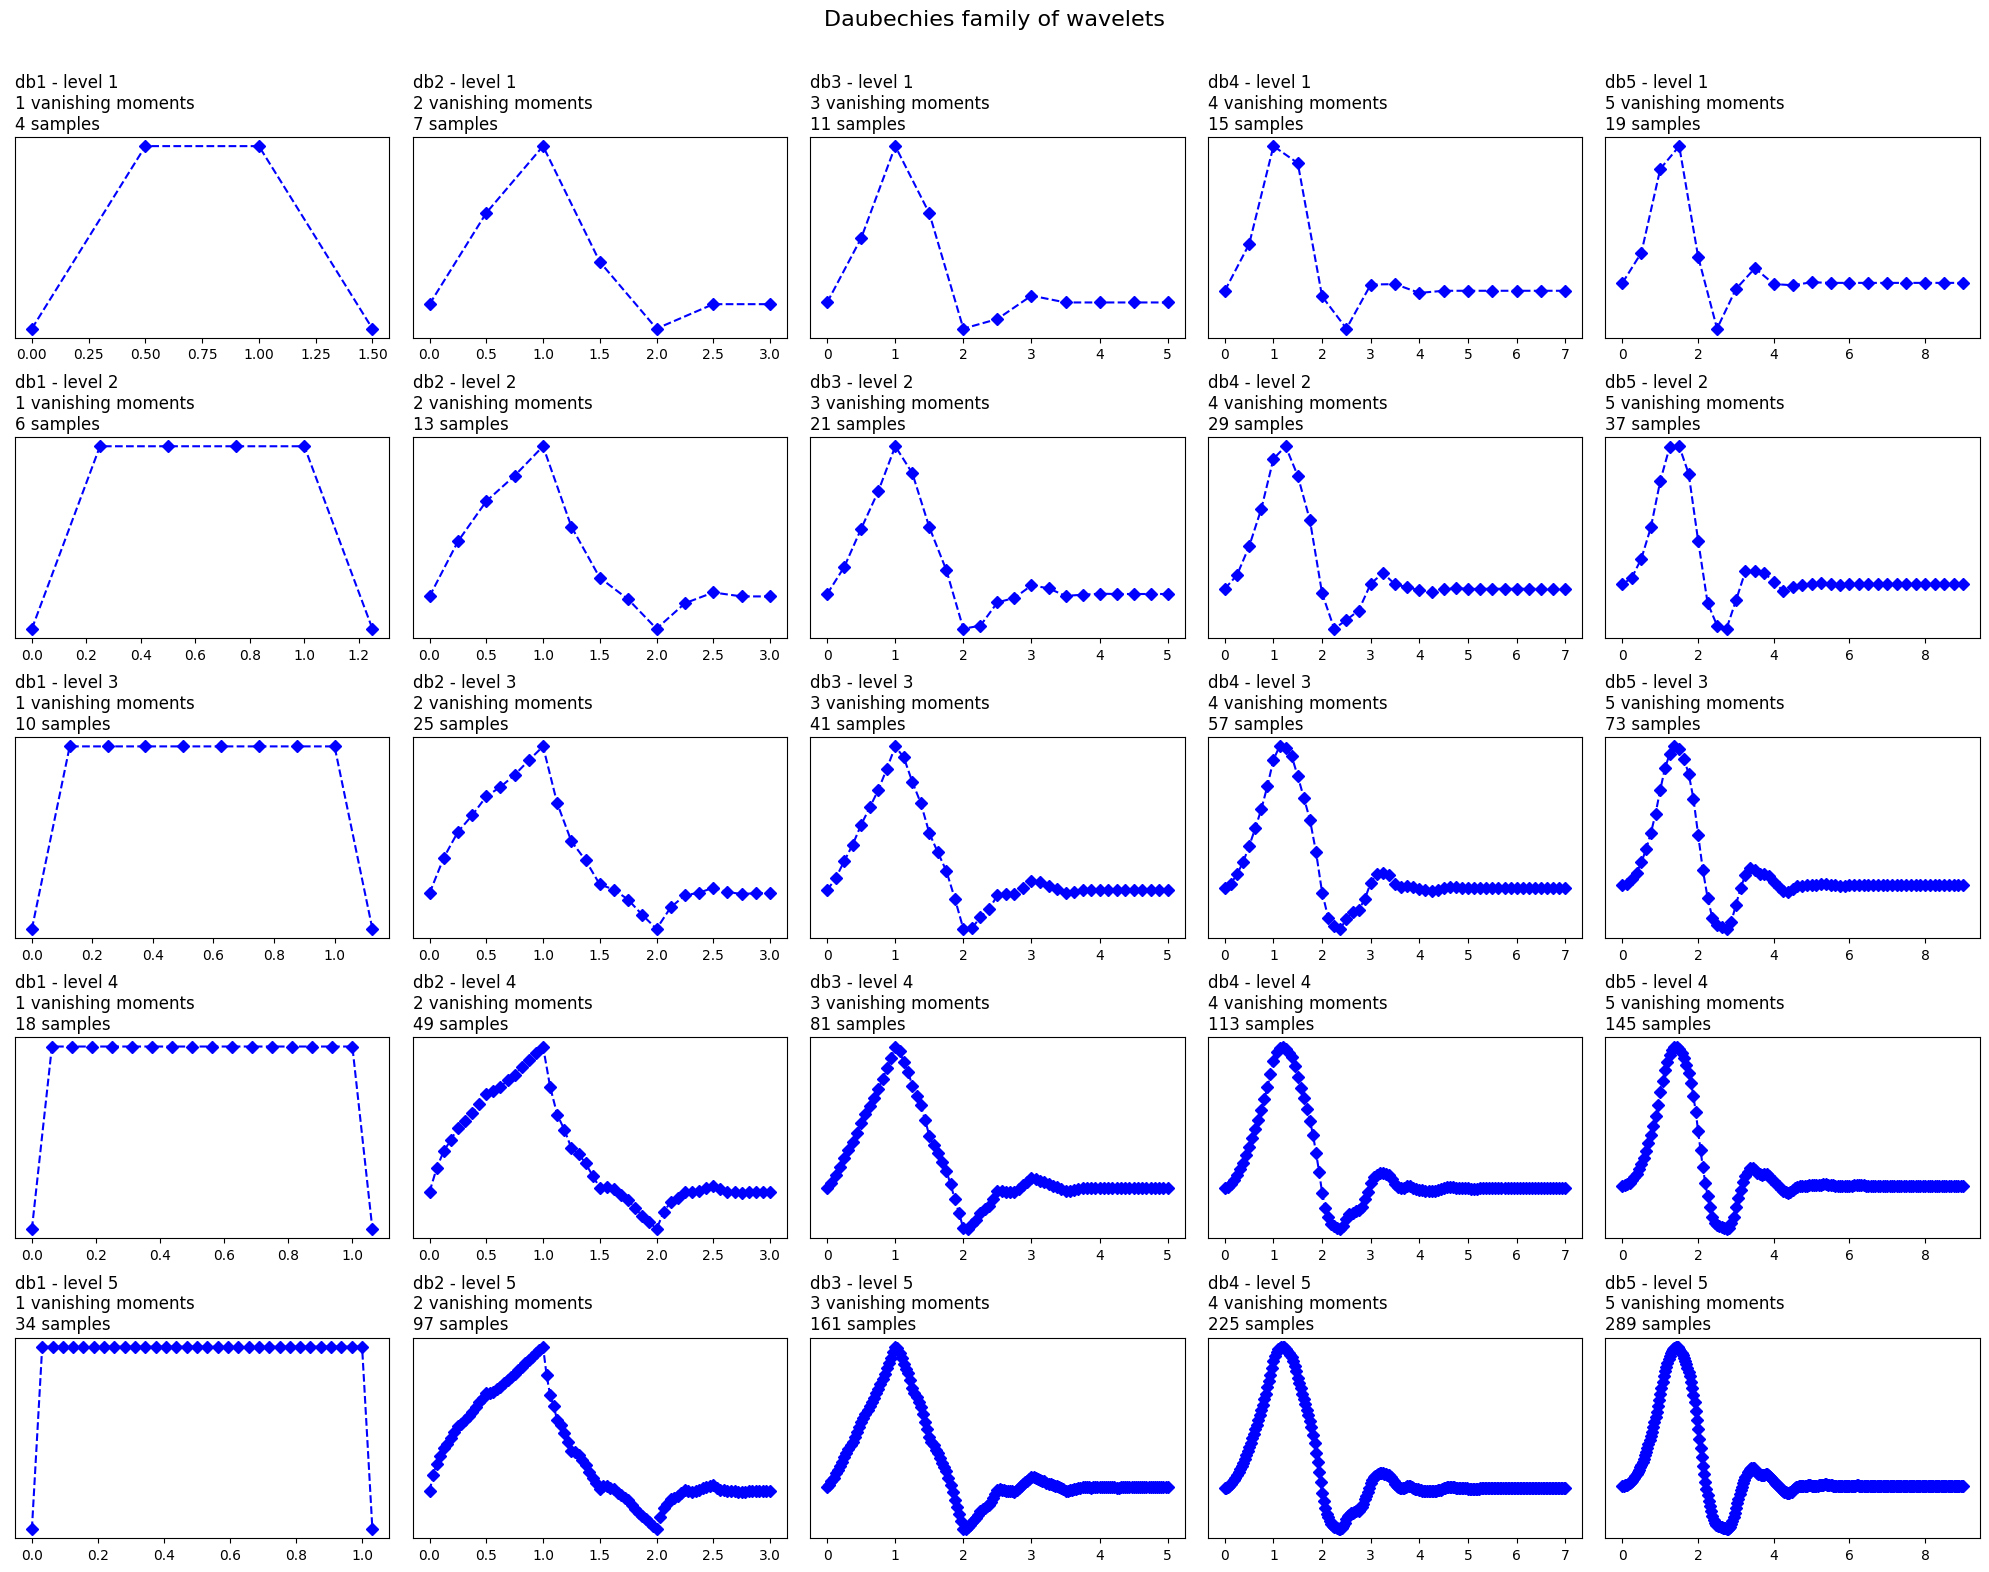

In [6]:
fig, axarr = plt.subplots(ncols=5, nrows=5, figsize=(20,16))
fig.suptitle('Daubechies family of wavelets', fontsize=16)

db_wavelets = pywt.wavelist('db')[:5]
for col_no, waveletname in enumerate(db_wavelets):
    wavelet = pywt.Wavelet(waveletname)
    no_moments = wavelet.vanishing_moments_psi
    family_name = wavelet.family_name
    for row_no, level in enumerate(range(1,6)):
        wavelet_function, scaling_function, x_values = wavelet.wavefun(level = level)
        axarr[row_no, col_no].set_title("{} - level {}\n{} vanishing moments\n{} samples".format(
            waveletname, level, no_moments, len(x_values)), loc='left')
        axarr[row_no, col_no].plot(x_values, wavelet_function, 'bD--')
        axarr[row_no, col_no].set_yticks([])
        axarr[row_no, col_no].set_yticklabels([])
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

4.A Using the pywt.dwt() for the decomposition of a signal into the frequency sub-bands
(and reconstrucing it again)

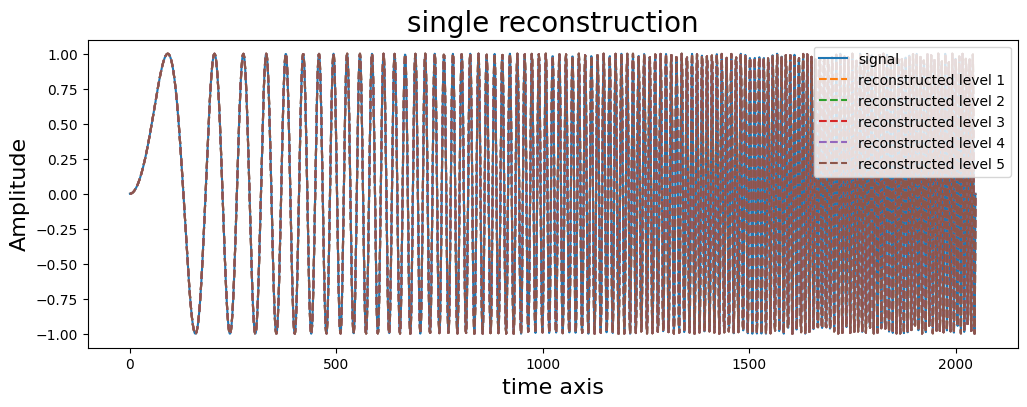

In [7]:
time = np.linspace(0, 1, num=2048)
chirp_signal = np.sin(250 * np.pi * time**2)

(cA1, cD1) = pywt.dwt(chirp_signal, 'db2', 'smooth')
(cA2, cD2) = pywt.dwt(cA1, 'db2', 'smooth')
(cA3, cD3) = pywt.dwt(cA2, 'db2', 'smooth')
(cA4, cD4) = pywt.dwt(cA3, 'db2', 'smooth')
(cA5, cD5) = pywt.dwt(cA4, 'db2', 'smooth')

coefficients_level1 = [cA1, cD1]
coefficients_level2 = [cA2, cD2, cD1]
coefficients_level3 = [cA3, cD3, cD2, cD1]
coefficients_level4 = [cA4, cD4, cD3, cD2, cD1]
coefficients_level5 = [cA5, cD5, cD4, cD3, cD2, cD1]

reconstructed_signal_level1 = pywt.waverec(coefficients_level1, 'db2', 'smooth')
reconstructed_signal_level2 = pywt.waverec(coefficients_level2, 'db2', 'smooth')
reconstructed_signal_level3 = pywt.waverec(coefficients_level3, 'db2', 'smooth')
reconstructed_signal_level4 = pywt.waverec(coefficients_level4, 'db2', 'smooth')
reconstructed_signal_level5 = pywt.waverec(coefficients_level5, 'db2', 'smooth')

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(chirp_signal, label='signal')
ax.plot(reconstructed_signal_level1, label='reconstructed level 1', linestyle='--')
ax.plot(reconstructed_signal_level2, label='reconstructed level 2', linestyle='--')
ax.plot(reconstructed_signal_level3, label='reconstructed level 3', linestyle='--')
ax.plot(reconstructed_signal_level4, label='reconstructed level 4', linestyle='--')
ax.plot(reconstructed_signal_level5, label='reconstructed level 5', linestyle='--')
ax.legend(loc='upper right')
ax.set_title('single reconstruction', fontsize=20)
ax.set_xlabel('time axis', fontsize=16)
ax.set_ylabel('Amplitude', fontsize=16)
plt.show()

4.B Using the pywt.wavedec() for the decomposition of a signal into the frequency sub-bands
(and reconstrucing it again)

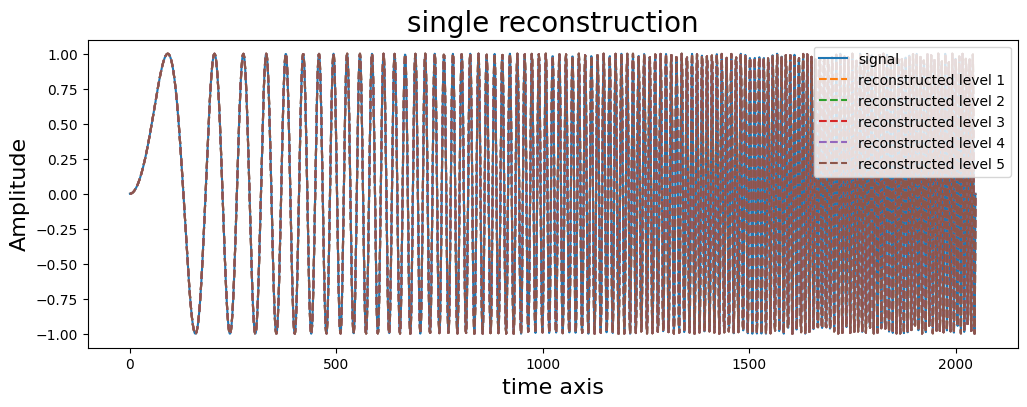

In [8]:
time = np.linspace(0, 1, num=2048)
chirp_signal = np.sin(250 * np.pi * time**2)

coefficients_level1 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=1)
coefficients_level2 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=2)
coefficients_level3 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=3)
coefficients_level4 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=4)
coefficients_level5 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=5)

reconstructed_signal_level1 = pywt.waverec(coefficients_level1, 'db2', 'smooth')
reconstructed_signal_level2 = pywt.waverec(coefficients_level2, 'db2', 'smooth')
reconstructed_signal_level3 = pywt.waverec(coefficients_level3, 'db2', 'smooth')
reconstructed_signal_level4 = pywt.waverec(coefficients_level4, 'db2', 'smooth')
reconstructed_signal_level5 = pywt.waverec(coefficients_level5, 'db2', 'smooth')

fig, ax = plt.subplots(figsize=(12,4))
ax.plot(chirp_signal, label='signal')
ax.plot(reconstructed_signal_level1, label='reconstructed level 1', linestyle='--')
ax.plot(reconstructed_signal_level2, label='reconstructed level 2', linestyle='--')
ax.plot(reconstructed_signal_level3, label='reconstructed level 3', linestyle='--')
ax.plot(reconstructed_signal_level4, label='reconstructed level 4', linestyle='--')
ax.plot(reconstructed_signal_level5, label='reconstructed level 5', linestyle='--')
ax.legend(loc='upper right')
ax.set_title('single reconstruction', fontsize=20)
ax.set_xlabel('time axis', fontsize=16)
ax.set_ylabel('Amplitude', fontsize=16)
plt.show()

5. Reconstrucing a signal with only one level of coefficients

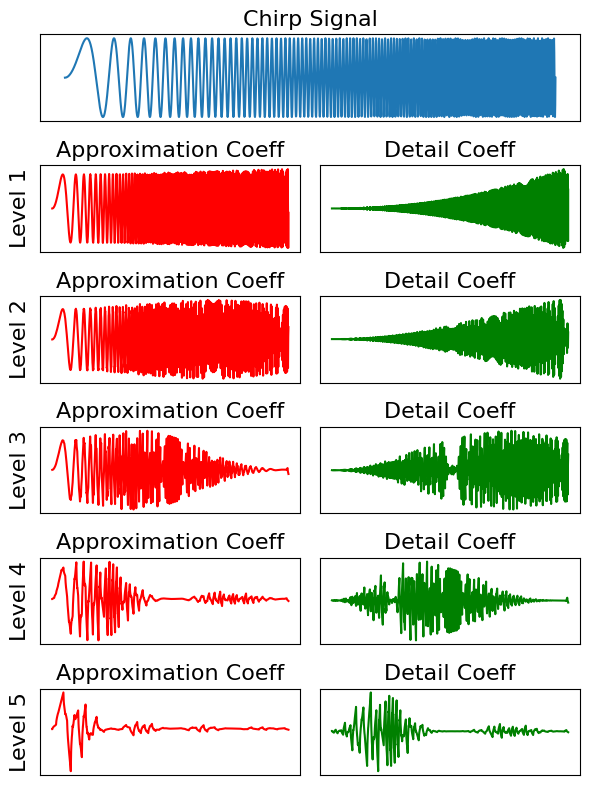

In [9]:
import matplotlib.gridspec as gridspec

fig = plt.figure(figsize=(6,8))
spec = gridspec.GridSpec(ncols=2, nrows=6)
ax0 = fig.add_subplot(spec[0, 0:2])
ax1a = fig.add_subplot(spec[1, 0])
ax1b = fig.add_subplot(spec[1, 1])
ax2a = fig.add_subplot(spec[2, 0])
ax2b = fig.add_subplot(spec[2, 1])
ax3a = fig.add_subplot(spec[3, 0])
ax3b = fig.add_subplot(spec[3, 1])
ax4a = fig.add_subplot(spec[4, 0])
ax4b = fig.add_subplot(spec[4, 1])
ax5a = fig.add_subplot(spec[5, 0])
ax5b = fig.add_subplot(spec[5, 1])
axarr = np.array([[ax1a, ax1b],[ax2a, ax2b],[ax3a, ax3b],[ax4a, ax4b],[ax5a, ax5b]])

time = np.linspace(0, 1, num=2048)
chirp_signal = np.sin(250 * np.pi * time**2)


# First we reconstruct a signal using pywt.wavedec() as we have also done at #4.2
coefficients_level1 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=1)
coefficients_level2 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=2)
coefficients_level3 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=3)
coefficients_level4 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=4)
coefficients_level5 = pywt.wavedec(chirp_signal, 'db2', 'smooth', level=5)

# pywt.wavedec() returns a list of coefficients. Below we assign these list of coefficients to variables explicitely.
[cA1_l1, cD1_l1] = coefficients_level1
[cA2_l2, cD2_l2, cD1_l2] = coefficients_level2
[cA3_l3, cD3_l3, cD2_l3, cD1_l3] = coefficients_level3
[cA4_l4, cD4_l4, cD3_l4, cD2_l4, cD1_l4] = coefficients_level4
[cA5_l5, cD5_l5, cD4_l5, cD3_l5, cD2_l5, cD1_l5] = coefficients_level5

# Since the the list of coefficients have been assigned explicitely to variables, we can set a few of them to zero.
approx_coeff_level1_only = [cA1_l1, None]
detail_coeff_level1_only = [None, cD1_l1]

approx_coeff_level2_only = [cA2_l2, None, None]
detail_coeff_level2_only = [None, cD2_l2, None]

approx_coeff_level3_only = [cA3_l3, None, None, None]
detail_coeff_level3_only = [None, cD3_l3, None, None]

approx_coeff_level4_only = [cA4_l4, None, None, None, None]
detail_coeff_level4_only = [None, cD4_l4, None, None, None]

approx_coeff_level5_only = [cA5_l5, None, None, None, None, None]
detail_coeff_level5_only = [None, cD5_l5, None, None, None, None]


# By reconstrucing the signal back from only one set of coefficients, we can see how 
# the frequency-sub band for that specific set of coefficient looks like
rec_signal_cA_level1 = pywt.waverec(approx_coeff_level1_only, 'db2', 'smooth')
rec_signal_cD_level1 = pywt.waverec(detail_coeff_level1_only, 'db2', 'smooth')

rec_signal_cA_level2 = pywt.waverec(approx_coeff_level2_only, 'db2', 'smooth')
rec_signal_cD_level2 = pywt.waverec(detail_coeff_level2_only, 'db2', 'smooth')

rec_signal_cA_level3 = pywt.waverec(approx_coeff_level3_only, 'db2', 'smooth')
rec_signal_cD_level3 = pywt.waverec(detail_coeff_level3_only, 'db2', 'smooth')

rec_signal_cA_level4 = pywt.waverec(approx_coeff_level4_only, 'db2', 'smooth')
rec_signal_cD_level4 = pywt.waverec(detail_coeff_level4_only, 'db2', 'smooth')

rec_signal_cA_level5 = pywt.waverec(approx_coeff_level5_only, 'db2', 'smooth')
rec_signal_cD_level5 = pywt.waverec(detail_coeff_level5_only, 'db2', 'smooth')


ax0.set_title("Chirp Signal", fontsize=16)
ax0.plot(time, chirp_signal)
ax0.set_xticks([])
ax0.set_yticks([])
ax1a.plot(rec_signal_cA_level1, color='red')
ax1b.plot(rec_signal_cD_level1, color='green')
ax2a.plot(rec_signal_cA_level2, color='red')
ax2b.plot(rec_signal_cD_level2, color='green')
ax3a.plot(rec_signal_cA_level3, color='red')
ax3b.plot(rec_signal_cD_level3, color='green')
ax4a.plot(rec_signal_cA_level4, color='red')
ax4b.plot(rec_signal_cD_level4, color='green')
ax5a.plot(rec_signal_cA_level5, color='red')
ax5b.plot(rec_signal_cD_level5, color='green')

for ii in range(0,5):
    axarr[ii,0].set_xticks([])
    axarr[ii,0].set_yticks([])
    axarr[ii,1].set_xticks([])
    axarr[ii,1].set_yticks([])
    axarr[ii,0].set_title("Approximation Coeff", fontsize=16)
    axarr[ii,1].set_title("Detail Coeff", fontsize=16)
    axarr[ii,0].set_ylabel("Level {}".format(ii+1), fontsize=16)
plt.tight_layout()
plt.show()

## Wavelet central frequency


For wavelets of family shan or cmor, the name should take the form cmorB-C 
where B and C are floats representing the bandwidth frequency and center 
frequency, respectively. (example: cmor1.5-1.0)"


wavelet [cmor1.5-1.0] has central frequecy: 1.0
ContinuousWavelet cmor1.5-1.0
  Family name:    Complex Morlet wavelets
  Short name:     cmor
  Symmetry:       asymmetric
  DWT:            False
  CWT:            True
  Complex CWT:    True
['cmor']


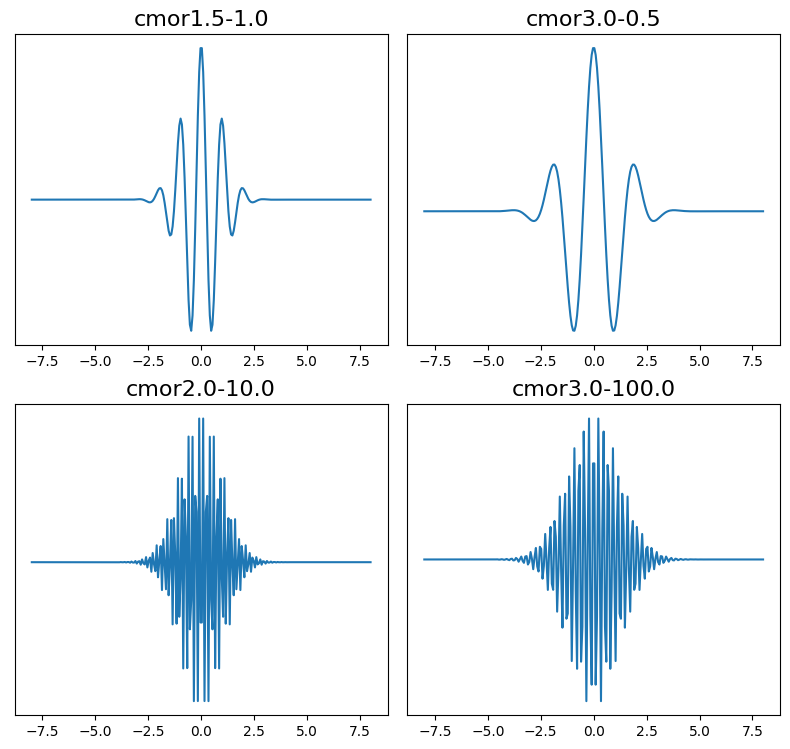

In [10]:
wavelet_name = 'cmor1.5-1.0'
wavelet_cmor = pywt.ContinuousWavelet(wavelet_name)
print(f'wavelet [{wavelet_name}] has central frequecy: {pywt.central_frequency(wavelet_cmor)}')
print(wavelet_cmor)
print(pywt.wavelist('cmor', kind='all'))
            
wl_list = [ 'cmor1.5-1.0', 'cmor3.0-0.5', 'cmor2.0-10.0', 'cmor3.0-100.0']
fig, axarr = plt.subplots(nrows=2, ncols=2, figsize=(8,8))

for ii, wn in enumerate(wl_list):
    row_no = ii // 2
    col_no = ii % 2

    wavelet = pywt.ContinuousWavelet(wn)
    wavelet_function, x_values = wavelet.wavefun()
    axarr[row_no, col_no].set_title(wn, fontsize=16)
    axarr[row_no, col_no].plot(x_values, wavelet_function)
    axarr[row_no, col_no].set_yticks([])
    axarr[row_no, col_no].set_yticklabels([])

plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()

## wavefun and level

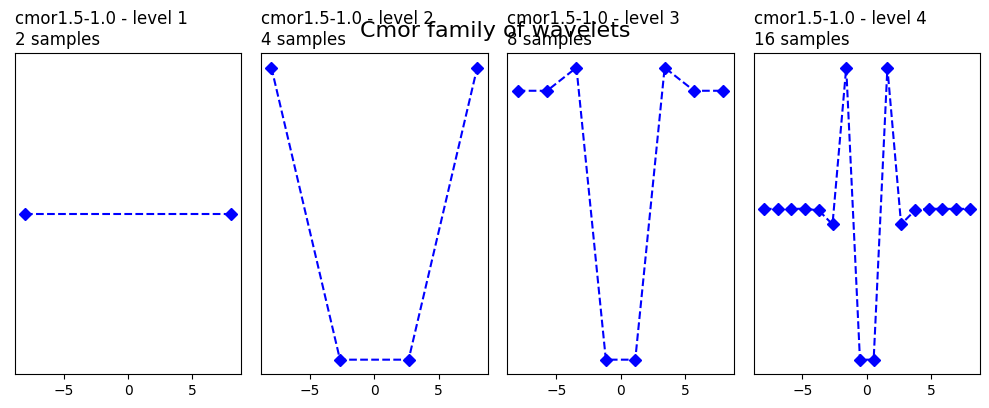

In [11]:
fig, axarr = plt.subplots(ncols=4, nrows=1, figsize=(10,4))
fig.suptitle('Cmor family of wavelets', fontsize=16)

family_name = wavelet_cmor.family_name
for col_no, level in enumerate(range(1,5)):
    wavelet_function, x_values = wavelet.wavefun(level = level)
    axarr[col_no].set_title(f"{wavelet_name} - level {level}\n{len(x_values)} samples", loc='left')
    axarr[col_no].plot(x_values, wavelet_function, 'bD--')
    axarr[col_no].set_yticks([])
    axarr[col_no].set_yticklabels([])
plt.tight_layout()
plt.subplots_adjust(top=0.9)
plt.show()